# DS 5110 Final Project — Predicting Contribution Party from Donor-Level Features

This notebook predicts the recipient party (Democrat/Republican/Other) of an individual
political contribution from donor-level features, using Stanford DIME's itemized
`ContribDB` file:

- Donor **occupation** (bucketed via top-N frequency + fuzzy/synonym matching)
- Donor **state** and **gender**
- **Contribution amount**
- **Transaction type** and **contributor type**
- Recipient **seat** and **election type** context

This is a different prediction task, at a different grain, than predicting a
candidate/committee's party from aggregate fundraising totals -- this notebook works
row-by-row on individual itemized contributions, not on recipient-level aggregates.

This notebook includes:

- Data import and preprocessing of the itemized ContribDB file
- Occupation feature engineering (fuzzy matching, synonym mapping)
- Donor-level train/test split (grouped by donor ID, so no donor leaks across both sets)
- EDA with tables and graphs on the donor-level data
- Three Spark ML models
- K-fold cross-validation and hyperparameter tuning
- Model evaluation with accuracy, precision, recall, F1, confusion matrices, and one-vs-rest AUROC
- Random Forest feature importance and Logistic Regression coefficient importance
- Champion model selection and hyperparameter sensitivity analysis

In [113]:
import os
import re
import gzip
import zipfile
import shutil
import urllib.request
from pathlib import Path
from typing import Optional, Sequence, List, Dict

import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark.storagelevel import StorageLevel

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.functions import vector_to_array

DATA_DIR = Path("./data/dime_fec_final_project")
DATA_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Download missing files from Stanford if needed.
DOWNLOAD_DATA_IF_MISSING = True

# If .csv.gz exists but .csv does not, decompress once.
# Uncompressed CSV generally lets Spark split the input better than one large .gz file.
DECOMPRESS_GZ_TO_CSV = True

# Itemized contribution donor-level model config
CONTRIB_MODEL_CYCLES = [2012]
CONTRIB_SAMPLE_FRACTION = 0.10
CONTRIB_MAX_TABLE_GB = 5.0

CONTRIB_MODEL_PARQUET = PROCESSED_DIR / (
    f"contrib_donor_party_model_{min(CONTRIB_MODEL_CYCLES)}_{max(CONTRIB_MODEL_CYCLES)}_parquet"
)
CONTRIB_TRAIN_PARQUET = PROCESSED_DIR / (
    f"contrib_donor_party_train_{min(CONTRIB_MODEL_CYCLES)}_{max(CONTRIB_MODEL_CYCLES)}_parquet"
)
CONTRIB_TEST_PARQUET = PROCESSED_DIR / (
    f"contrib_donor_party_test_{min(CONTRIB_MODEL_CYCLES)}_{max(CONTRIB_MODEL_CYCLES)}_parquet"
)
READ_CONTRIB_MODEL_IF_EXISTS = False
WRITE_CONTRIB_MODEL_PARQUET = True
FORCE_REBUILD_CONTRIB_MODEL = False

OCCUPATION_TOP_N = 250

# Keep expensive debug actions controlled.
SHOW_DEBUG = True
RUN_EXPENSIVE_COUNTS = True
MAKE_GRAPHS = True

TEST_FRACTION = 0.2
RANDOM_SEED = 42

# Cross-validation/hyperparameter tuning controls.
FAST_CV = True
NUM_FOLDS = 3

# Spark partition controls
NUM_CORES = int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count() or 8))
SHUFFLE_PARTITIONS = max(32, NUM_CORES * 4)
MODEL_PARTITIONS = max(16, NUM_CORES * 2)

print("Contrib model cycles:", CONTRIB_MODEL_CYCLES)
print("NUM_CORES:", NUM_CORES)
print("SHUFFLE_PARTITIONS:", SHUFFLE_PARTITIONS)
print("MODEL_PARTITIONS:", MODEL_PARTITIONS)

Contrib model cycles: [2012]
NUM_CORES: 8
SHUFFLE_PARTITIONS: 32
MODEL_PARTITIONS: 16


In [114]:
spark = (
    SparkSession.builder
    .appName("Contrib_Donor_Party_Modeling")
    .master(f"local[{NUM_CORES}]")
    .config("spark.sql.shuffle.partitions", str(SHUFFLE_PARTITIONS))
    .config("spark.default.parallelism", str(SHUFFLE_PARTITIONS))
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.adaptive.skewJoin.enabled", "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print("Spark master:", spark.sparkContext.master)
print("Default parallelism:", spark.sparkContext.defaultParallelism)
print("Shuffle partitions:", spark.conf.get("spark.sql.shuffle.partitions"))

Spark master: local[8]
Default parallelism: 32
Shuffle partitions: 32


# File paths and download helpers

In [115]:
contrib_urls = {
    2012: "https://www.dropbox.com/scl/fi/dx8tafolqtrgp2dbn4fg6/contribDB_2012.csv.gz?rlkey=sslqxjhubk9745pfb0shcq5k4&dl=1",
    2014: "https://www.dropbox.com/scl/fi/g0omy5h86mddmwcai43fk/contribDB_2014.csv.gz?rlkey=btee8x45og1vphwpvnfe9qttg&dl=1",
    2016: "https://www.dropbox.com/scl/fi/qg5vezrx876cmu7u9hehr/contribDB_2016.csv.gz?rlkey=dsl4htd0ovr8hyn7xwctel0a0&dl=1",
    2018: "https://www.dropbox.com/scl/fi/sk2fbjbrq7hgdqfnern2g/contribDB_2018.csv.gz?rlkey=qsk4o1wjc8p1bwozuuk4bwq01&dl=1",
    2020: "https://www.dropbox.com/scl/fi/rnmdp79g0ewbf9j68tz1s/contribDB_2020.csv.gz?rlkey=v3y2xuvnmqueaiwkllls81mul&dl=1",
    2022: "https://www.dropbox.com/scl/fi/odu6raws98gu1xdmx0ql3/contribDB_2022.csv.gz?rlkey=bvrmhaftpp2sa6tv3lu120v44&dl=1",
    2024: "https://www.dropbox.com/scl/fi/p3adbtd50033ilt5ir3n2/contribDB_2024.csv.gz?rlkey=gt8l9j6xoi6h07syr94f33oyv&dl=1"
}

# CONTRIB data folder
CONTRIB_DIR = DATA_DIR / "contrib"
CONTRIB_DIR.mkdir(parents=True, exist_ok=True)

def path_size_gb(path: Path) -> float:
    '''
    Return the size of a file or directory in GB.
    '''
    if not path.exists():
        return 0.0
    if path.is_file():
        return path.stat().st_size / 1024**3
    total = 0
    for p in path.rglob("*"):
        if p.is_file():
            total += p.stat().st_size
    return total / 1024**3

def download_if_missing(url: str, out_path: Path, enabled: bool = True) -> None:
    '''
    Download a file from a URL to a local path if it does not already exist.
    '''
    if out_path.exists() and out_path.stat().st_size > 0:
        print("Already exists:", out_path, "GB:", round(path_size_gb(out_path), 3))
        return
    if not enabled:
        print("Download disabled; missing:", out_path)
        return

    print("Downloading:", out_path)
    print("From:", url)
    urllib.request.urlretrieve(url, out_path)
    print("Downloaded:", out_path, "GB:", round(path_size_gb(out_path), 3))

def decompress_gz_if_needed(gz_path: Path, csv_path: Path) -> Path:
    '''
    Decompress a .gz file to .csv if needed, and return the path to the resulting CSV.
    If the CSV already exists, it will be used directly.
    If the .gz file 
    does not exist, an error will be raised.
    '''
    if csv_path.exists() and csv_path.stat().st_size > 0:
        print("Using existing CSV:", csv_path, "GB:", round(path_size_gb(csv_path), 3))
        return csv_path

    if not gz_path.exists():
        raise FileNotFoundError(f"Missing both CSV and GZ: {csv_path} / {gz_path}")

    if not DECOMPRESS_GZ_TO_CSV:
        print("Using GZ directly:", gz_path)
        return gz_path

    free_gb = shutil.disk_usage(str(DATA_DIR)).free / 1024**3
    print("Free disk GB:", round(free_gb, 2))
    print("Decompressing:", gz_path, "->", csv_path)
    with gzip.open(gz_path, "rb") as f_in:
        with open(csv_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)
    print("Created:", csv_path, "GB:", round(path_size_gb(csv_path), 3))
    return csv_path

def parquet_has_data(path: Path) -> bool:
    '''
    Check if a Parquet directory has data by looking for a _SUCCESS file or any .parquet files.
    '''
    if not path.exists():
        return False
    if (path / "_SUCCESS").exists():
        return True
    return any(path.rglob("*.parquet"))

need_raw_contrib_files = not (
    READ_CONTRIB_MODEL_IF_EXISTS and not FORCE_REBUILD_CONTRIB_MODEL and parquet_has_data(CONTRIB_MODEL_PARQUET)
)

CONTRIB_MODEL_INPUTS = {}
if need_raw_contrib_files:
    for cyc in CONTRIB_MODEL_CYCLES:
        gz_path = CONTRIB_DIR / f"contribDB_{cyc}.csv.gz"
        csv_path = CONTRIB_DIR / f"contribDB_{cyc}.csv"
        if not csv_path.exists() and not gz_path.exists():
            download_if_missing(contrib_urls[cyc], gz_path, DOWNLOAD_DATA_IF_MISSING)
        CONTRIB_MODEL_INPUTS[cyc] = decompress_gz_if_needed(gz_path, csv_path)
        print("Fetched raw contrib model inputs:", CONTRIB_MODEL_INPUTS)
else:
    print("Skipping raw ContribDB download/decompress -- CONTRIB_MODEL_PARQUET cache already covers this run (and FORCE_REBUILD_CONTRIB_MODEL is False).")



Using existing CSV: data/dime_fec_final_project/contrib/contribDB_2012.csv GB: 4.788
Fetched raw contrib model inputs: {2012: PosixPath('data/dime_fec_final_project/contrib/contribDB_2012.csv')}


# Robust utility functions

In [116]:
def safe_name(name: str) -> str:
    '''
    Convert a string to a safe column name by:
    - Lowercasing
    - Replacing non-alphanumeric characters with underscores
    - Collapsing multiple underscores into one
    - Stripping leading/trailing underscores
    - If the result is empty, return "col"
    - If the result starts with a digit, prefix with "c_"
    '''
    name = str(name).strip().lower()
    name = re.sub(r"[^0-9a-zA-Z]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    if not name:
        name = "col"
    if re.match(r"^\d", name):
        name = "c_" + name
    return name


def dedupe_names(names: Sequence[str]) -> List[str]:
    '''
    Deduplicate a list of column names by appending _1, _2, etc. to duplicates.
    Returns a new list of unique names.
    '''
    seen = {}
    out = []
    for n in names:
        base = safe_name(n)
        if base not in seen:
            seen[base] = 0
            out.append(base)
        else:
            seen[base] += 1
            out.append(f"{base}_{seen[base]}")
    return out


def qcol(name: str) -> str:
    '''
    Quote a column name for use in Spark SQL expressions, escaping backticks.
    '''
    return "`" + str(name).replace("`", "``") + "`"


def try_double_expr(expr_sql: str):
    '''
    Return a Spark SQL expression that safely casts a string expression to double, returning NULL on failure.
    '''
    return F.expr(f"try_cast({expr_sql} as double)")


def clean_double_col(col_name: str):
    '''
    Return a Spark SQL expression that safely cleans and casts a column to double, returning NULL on failure.
    '''
    return F.expr(
        f"try_cast(nullif(trim(regexp_replace(cast({qcol(col_name)} as string), '[$,]', '')), '') as double)"
    )


def read_csv_strings(path: Path) -> DataFrame:
    '''
    Read a CSV file into a Spark DataFrame, treating all columns as strings and handling corrupt records.
    Deduplicates column names to ensure uniqueness.
    '''
    df = (
        spark.read
        .option("header", True)
        .option("inferSchema", False)
        .option("multiLine", False)
        .option("mode", "PERMISSIVE")
        .option("quote", '"')
        .option("escape", '"')
        .option("columnNameOfCorruptRecord", "_corrupt_record")
        .csv(str(path))
    )
    df = df.toDF(*dedupe_names(df.columns))
    return df


def first_present(df: DataFrame, candidates: Sequence[str]) -> Optional[str]:
    '''
    Return the first column name from candidates that is present in the DataFrame, after applying safe_name.
    If none are present, return None.
    '''
    cols = set(df.columns)
    for c in candidates:
        c_safe = safe_name(c)
        if c_safe in cols:
            return c_safe
    return None


def party_group_expr(c):
    '''
    Return a Spark SQL expression that maps various party identifiers to standardized party groups.
    '''
    x = F.upper(F.trim(c.cast("string")))
    return (
        F.when(x.isin("100", "D", "DEM", "DEMOCRAT", "DEMOCRATIC", "DEMOCRATIC_FARMER_LABOR", "DFL"), "DEMOCRAT")
         .when(x.isin("200", "R", "REP", "REPUBLICAN", "GOP"), "REPUBLICAN")
         .when(x.isNull() | (x == ""), None)
         .otherwise("OTHER")
    )


def ideology_group_expr(c):
    '''
    Return a Spark SQL expression that maps numeric ideology scores to categorical groups.    
    '''
    # c should usually already be numeric, but use cast safely after earlier clean_double_col.
    x = c.cast("double")
    return (
        F.when(x <= -0.25, "LEFT_LEANING")
         .when(x >= 0.25, "RIGHT_LEANING")
         .when(x.isNull(), None)
         .otherwise("MODERATE")
    )


def clean_cat(c):
    '''
    Return a Spark SQL expression that safely cleans a categorical column by trimming, uppercasing, and replacing nulls with "MISSING".
    '''
    return F.coalesce(F.upper(F.trim(c.cast("string"))), F.lit("MISSING"))


def show_df(df: DataFrame, n: int = 20, truncate: bool = False) -> None:
    '''
    Show the first n rows of a DataFrame, with optional truncation.
    '''
    df.show(n, truncate=truncate)


def safe_ratio(num_col, den_col):
    '''
    Return a Spark SQL expression that safely computes the ratio of two columns, returning 0.0 if the denominator is zero or null.
    '''
    return F.when(F.col(den_col) > 0, F.col(num_col) / F.col(den_col)).otherwise(F.lit(0.0))

# Raw data size summary

In [117]:
raw_size_rows = []

if need_raw_contrib_files:
    for cyc, path in CONTRIB_MODEL_INPUTS.items():
        raw_size_rows.append((f'{cyc} contributions', str(path), path_size_gb(Path(path))))

    raw_size_df = spark.createDataFrame(raw_size_rows, ["source", "path", "size_gb"])
    show_df(raw_size_df.orderBy(F.desc("size_gb")), 100, truncate=False)

    print("Approximate raw input size GB:", round(sum(r[2] for r in raw_size_rows), 3))

+------------------+------------------------------------------------------+---------------+
|source            |path                                                  |size_gb        |
+------------------+------------------------------------------------------+---------------+
|2012 contributions|data/dime_fec_final_project/contrib/contribDB_2012.csv|4.7884521484375|
+------------------+------------------------------------------------------+---------------+

Approximate raw input size GB: 4.788


# DataFrame cleanup helpers

In [ ]:
def unique_column_names(cols):
    """
    Return unique column names by suffixing duplicates.
    """
    seen = {}
    out = []
    for c in cols:
        if c not in seen:
            seen[c] = 0
            out.append(c)
        else:
            seen[c] += 1
            out.append(f"{c}_dup{seen[c]}")
    return out

def make_columns_unique(df: DataFrame) -> DataFrame:
    """
    Spark can hold duplicate names after joins; Parquet writes cannot.
    """
    new_cols = unique_column_names(df.columns)
    if new_cols != df.columns:
        print("Duplicate column names detected and renamed.")
        return df.toDF(*new_cols)
    return df

def parquet_has_data(path: Path) -> bool:
    if not path.exists():
        return False
    if (path / "_SUCCESS").exists():
        return True
    return any(path.rglob("*.parquet"))

# Helpers for creating occupation categories

def clean_free_text(c):
    x = F.upper(F.trim(c.cast("string")))
    x = F.regexp_replace(x, r"[^A-Z0-9 ]", " ")
    x = F.regexp_replace(x, r"\s+", " ")
    x = F.trim(x)
    return F.when(
        x.isNull() | (x == "") | x.isin("NA", "N A", "NONE", "NOT EMPLOYED", "UNEMPLOYED"),
        "UNKNOWN"
    ).otherwise(x)

def top_n_category_values(fit_df: DataFrame, col_name: str, n: int) -> list:
    '''
    Return the top n most frequent values in a categorical column of a DataFrame.
    '''
    rows = (
        fit_df.groupBy(col_name)
        .count()
        .orderBy(F.desc("count"))
        .limit(n)
        .select(col_name)
        .collect()
    )
    return [r[col_name] for r in rows]

def apply_category_bucket(df, col_name, keep_values, out_col, other_label="OTHER"):
    '''
    Return a DataFrame with a new column that buckets the values of col_name into keep_values, labeling all other values as other_label.
    '''
    return df.withColumn(
        out_col,
        F.when(F.col(col_name).isin(keep_values), F.col(col_name)).otherwise(F.lit(other_label))
    )

def apply_synonym_map(c, synonym_map: dict):
    '''
    Return a Spark SQL expression that maps values in a column according to a synonym map, returning the original value if no mapping exists.
    '''
    mapping_expr = F.create_map([F.lit(x) for pair in synonym_map.items() for x in pair])
    return F.coalesce(mapping_expr.getItem(c), c)

def word_boundary_contains(text_col, phrase_col):
    '''
    Return a Spark SQL expression that checks if phrase_col is contained in text_col as a whole word or phrase, using word boundaries.
    '''
    padded_text = F.concat(F.lit(" "), text_col, F.lit(" "))
    padded_phrase = F.concat(F.lit(" "), phrase_col, F.lit(" "))
    return padded_text.contains(padded_phrase)

def build_fuzzy_category_map(
    fit_df, col_name, canonical_labels, max_norm_distance=0.2, min_len=3, contains_exclude=None,
) -> DataFrame:
    '''
    Build a fuzzy matching map from distinct values in fit_df[col_name] to canonical_labels.
    Returns a DataFrame with columns [col_name, fuzzy_canonical].
    '''
    contains_exclude = contains_exclude or set()
    canonical_col = f"{col_name}_canonical"

    distinct_vals = (
        fit_df.select(col_name).distinct()
        .filter(F.col(col_name).isNotNull() & (F.length(col_name) >= min_len))
        .filter(~F.col(col_name).isin(canonical_labels))
    )
    canonical_df = spark.createDataFrame([(c,) for c in canonical_labels], [canonical_col])

    scored = (
        distinct_vals.crossJoin(F.broadcast(canonical_df))
        .withColumn("edit_dist", F.levenshtein(F.col(col_name), F.col(canonical_col)))
        .withColumn("max_len", F.greatest(F.length(col_name), F.length(canonical_col)))
        .withColumn("norm_dist", F.col("edit_dist") / F.col("max_len"))
        .withColumn(
            "raw_contains_match",
            # Whole-word/phrase match only -- fixes false positives like "COORDINATOR" matching "COO".
            word_boundary_contains(F.col(col_name), F.col(canonical_col))
            | word_boundary_contains(F.col(canonical_col), F.col(col_name))
        )
        .withColumn(
            "contains_match",
            F.col("raw_contains_match") & ~F.col(canonical_col).isin(list(contains_exclude))
        )
    )

    w = Window.partitionBy(col_name).orderBy(F.col("contains_match").desc(), F.col("norm_dist").asc())

    best = (
        scored
        .withColumn("rn", F.row_number().over(w))
        .filter(F.col("rn") == 1)
        .filter(F.col("contains_match") | (F.col("norm_dist") <= max_norm_distance))
        .select(col_name, F.col(canonical_col).alias("fuzzy_canonical"))
    )
    return best

def build_bucket_with_fuzzy_match(
    fit_df, apply_df, col_name, top_n, out_col,
    synonym_map=None, max_norm_distance=0.2, contains_exclude=None, other_label="OTHER",
):
    '''
    Build a new column in apply_df that buckets values of col_name into the top_n most frequent values from fit_df,
    applying a synonym map and fuzzy matching to canonical labels. All other values are labeled as other_label.
    Returns a tuple of (result_df, canonical_labels, fuzzy_map_df).'''
    working_col = col_name
    if synonym_map:
        apply_df = apply_df.withColumn(f"{col_name}_syn", apply_synonym_map(F.col(col_name), synonym_map))
        fit_df = fit_df.withColumn(f"{col_name}_syn", apply_synonym_map(F.col(col_name), synonym_map))
        working_col = f"{col_name}_syn"

    canonical_labels = top_n_category_values(fit_df, working_col, top_n)
    fuzzy_map = build_fuzzy_category_map(
        fit_df, working_col, canonical_labels,
        max_norm_distance=max_norm_distance, contains_exclude=contains_exclude,
    )
    fuzzy_map = fuzzy_map.cache()

    result = (
        apply_df
        .join(F.broadcast(fuzzy_map), on=working_col, how="left")
        .withColumn(
            out_col,
            F.when(F.col(working_col).isin(canonical_labels), F.col(working_col))
             .when(F.col("fuzzy_canonical").isNotNull(), F.col("fuzzy_canonical"))
             .otherwise(F.lit(other_label))
        )
        .drop("fuzzy_canonical")
    )
    return result, canonical_labels, fuzzy_map

# Build contributions base modeling table

In [ ]:
# Column names we expect in the itemized ContribDB files (see codebook section 5.3).
CONTRIB_RAW_COLUMN_CANDIDATES = {
    "bonica_cid": ["bonica.cid", "bonica_cid"],
    "bonica_rid": ["bonica.rid", "bonica_rid"],
    "amount": ["amount"],
    "date": ["date"],
    "transaction_type": ["transaction.type", "transaction_type"],
    "contributor_type": ["contributor.type", "contributor_type"],
    "contributor_gender": ["contributor.gender", "contributor_gender"],
    "contributor_occupation": ["contributor.occupation", "contributor_occupation"],
    "contributor_employer": ["contributor.employer", "contributor_employer"],
    "contributor_state": ["contributor.state", "contributor_state"],
    "contributor_zipcode": ["contributor.zipcode", "contributor_zipcode"],
    "recipient_party": ["recipient.party", "recipient_party"],
    "recipient_type": ["recipient.type", "recipient_type"],
    "recipient_state": ["recipient.state", "recipient_state"],
    "seat": ["seat"],
    "election_type": ["election.type", "election_type"],
}

def scol(key, colmap, default=None):
    src = colmap.get(key)
    return F.col(src) if src is not None else F.lit(default)

def contributor_type_recode_expr(c):
    return (
        F.when(c == "I", "Individual")
         .when(c == "C", "Committee/Org")
         .otherwise(c)
    )

def load_contrib_cycle_narrow(cycle: int, path: Path) -> DataFrame:
    print(f"Reading itemized contributions for cycle {cycle}: {path}")
    raw = read_csv_strings(path)

    if SHOW_DEBUG:
        print(f"  raw columns ({len(raw.columns)}):", raw.columns)

    colmap = {key: first_present(raw, cands) for key, cands in CONTRIB_RAW_COLUMN_CANDIDATES.items()}

    missing = [k for k, v in colmap.items() if v is None]
    if missing:
        print(f"  WARNING: missing expected columns for cycle {cycle}: {missing}")

    narrowed = raw.select(
        F.lit(int(cycle)).cast("int").alias("cycle"),
        scol("bonica_cid", colmap).cast("string").alias("bonica_cid"),
        scol("bonica_rid", colmap).cast("string").alias("bonica_rid"),
        (clean_double_col(colmap["amount"]) if colmap.get("amount") else F.lit(None).cast("double")).alias("amount"),
        scol("date", colmap).cast("string").alias("transaction_date_raw"),
        clean_cat(scol("transaction_type",colmap, "MISSING")).alias("transaction_type"),
        contributor_type_recode_expr(clean_cat(scol("contributor_type", colmap,"MISSING"))).alias("contributor_type"),
        clean_cat(scol("contributor_gender",colmap, "U")).alias("contributor_gender"),
        F.trim(scol("contributor_occupation",colmap, "")).alias("contributor_occupation_raw"),
        F.trim(scol("contributor_employer",colmap, "")).alias("contributor_employer_raw"),
        clean_cat(scol("contributor_state",colmap, "MISSING")).alias("contributor_state"),
        F.trim(scol("contributor_zipcode", colmap, "")).alias("contributor_zipcode_raw"),
        party_group_expr(scol("recipient_party", colmap)).alias("party_group"),
        clean_cat(scol("recipient_type", colmap, "MISSING")).alias("recipient_type_group"),
        clean_cat(scol("recipient_state",colmap, "MISSING")).alias("recipient_state_group"),
        clean_cat(scol("seat", colmap, "MISSING")).alias("seat_group"),
        clean_cat(scol("election_type", colmap, "MISSING")).alias("election_type_group"),
    )

    # Drop rows that no label, no donor id, no usable amount.
    narrowed = narrowed.filter(
        F.col("party_group").isNotNull()
        & F.col("bonica_cid").isNotNull() & (F.col("bonica_cid") != "")
        & F.col("amount").isNotNull() & (F.col("amount") > 0)
    )

    if CONTRIB_SAMPLE_FRACTION < 1.0:
        narrowed = narrowed.sample(withReplacement=False, fraction=CONTRIB_SAMPLE_FRACTION, seed=RANDOM_SEED)

    return narrowed

def build_contrib_model_table() -> DataFrame:
    if READ_CONTRIB_MODEL_IF_EXISTS and not FORCE_REBUILD_CONTRIB_MODEL and parquet_has_data(CONTRIB_MODEL_PARQUET):
        print("Reading existing contrib donor-level model Parquet:", CONTRIB_MODEL_PARQUET)
        return spark.read.parquet(str(CONTRIB_MODEL_PARQUET))

    pieces = [load_contrib_cycle_narrow(cyc, path) for cyc, path in CONTRIB_MODEL_INPUTS.items()]
    contrib_narrow = pieces[0]
    for piece in pieces[1:]:
        contrib_narrow = contrib_narrow.unionByName(piece, allowMissingColumns=True)

    contrib_narrow = make_columns_unique(contrib_narrow).repartition(MODEL_PARTITIONS, "cycle")

    if not WRITE_CONTRIB_MODEL_PARQUET:
        print("Using contrib model in lineage only; no Parquet write.")
        return contrib_narrow

    temp_path = PROCESSED_DIR / (
        f"_tmp_contrib_donor_party_model_{min(CONTRIB_MODEL_CYCLES)}_{max(CONTRIB_MODEL_CYCLES)}_parquet"
    )
    if temp_path.exists():
        shutil.rmtree(temp_path)

    print("Writing contrib donor-level model Parquet:", CONTRIB_MODEL_PARQUET)
    contrib_narrow.write.mode("overwrite").option("compression", "snappy").parquet(str(temp_path))

    out_size_gb = path_size_gb(temp_path)
    print("Contrib model table size GB:", round(out_size_gb, 3))

    if out_size_gb > CONTRIB_MAX_TABLE_GB:
        shutil.rmtree(temp_path, ignore_errors=True)
        raise RuntimeError(
            f"Contrib model table would be {out_size_gb:.2f} GB, above CONTRIB_MAX_TABLE_GB={CONTRIB_MAX_TABLE_GB}. "
            "Lower CONTRIB_SAMPLE_FRACTION or use fewer cycles."
        )

    if CONTRIB_MODEL_PARQUET.exists():
        shutil.rmtree(CONTRIB_MODEL_PARQUET)
    shutil.move(str(temp_path), str(CONTRIB_MODEL_PARQUET))

    return spark.read.parquet(str(CONTRIB_MODEL_PARQUET))

contrib_model_df = build_contrib_model_table()
contrib_model_df = contrib_model_df.cache()
contrib_model_df.count()  

In [100]:
if len(contrib_model_df.columns) == 17:
    print(u'\u2713 \u2713 \u2713'+ " Contrib model table has expected 17 columns.")
    # show_df(contrib_model_df.groupBy("party_group").count().orderBy(F.desc("count")), 10)

# Build occupation feature

In [ ]:
FUZZY_CONTAINS_EXCLUDE = {"DISABLED"}

OCCUPATION_SYNONYMS = {
    "LAWYER": "ATTORNEY", "ATTY": "ATTORNEY",
    "MD": "PHYSICIAN", "DOCTOR": "PHYSICIAN", "MEDICAL DOCTOR": "PHYSICIAN",
    "HOUSEWIFE": "HOMEMAKER", "STAY AT HOME PARENT": "HOMEMAKER",
    "SELFEMPLOYED": "SELF EMPLOYED", "SELF-EMPLOYED": "SELF EMPLOYED",
    "NOT EMPLOYED": "UNEMPLOYED", "NONE": "UNEMPLOYED",
    "SALESMAN": "SALES",
    "REFUSED": "UNKNOWN",
    "ADMIN": "ADMINISTRATOR", "ADMIN ASST": "ADMINISTRATIVE ASSISTANT", "ADMIN ASSISTANT": "ADMINISTRATIVE ASSISTANT",
    "POLITICAL ACTION COMMITTEE": "PAC",
    "ACTRESS": "ACTOR",
    "INFORMATION TECHNOLOGY": "IT",
    "FIRE CAPTAIN": "FIREFIGHTER",
    "GOVERNMENT AFFAIRS": "GOVERNMENT RELATIONS",
    "CHIEF FINANCIAL OFFICER": "CFO",
    "EXEC": "EXECUTIVE",
    "CLERICAL": "CLERK",
    "TRUCKING": "TRUCK DRIVER",
    "RETAILER": "RETAIL",
    "LIBRARY ASSISTANT": "LIBRARIAN",
    "CHAPLAIN": "CLERGY", "RABBI": "CLERGY", "PRIEST": "CLERGY",
    "TECH": "TECHNICIAN",
    "MOM": "HOMEMAKER",
    "GENERAL COUNSEL": "ATTORNEY",
    "LAW ENFORCEMENT": "POLICE OFFICER",
    "ENGINEERING": "ENGINEER",
    "BUILDER": "CONTRACTOR",
    "FINANCIAL SERVICES": "FINANCE",
    "INVESTMENT ADVISOR": "FINANCIAL ADVISOR", "FINANCIAL PLANNER": "FINANCIAL ADVISOR",
    "PSYCHOANALYST": "PSYCHOTHERAPIST",
    "ANESTHESIOLOGIST": "PHYSICIAN", "RADIOLOGIST": "PHYSICIAN",
    "TUTOR": "TEACHER",
    "FOUNDER": "ENTREPRENEUR",
    "PROGRAM COORDINATOR": "PROGRAM MANAGER",
    "LANDLORD": "REAL ESTATE",
    "MEDICAL": "HEALTHCARE",
    "AUDITOR": "ACCOUNTANT",
    "WRITEREDITOR": "WRITER",
    "EDITORWRITER": "WRITER",
    "AGRICULTURE": "FARMER",
    "OFFICE AND ADMINISTRATIVE OCCUPATIONS": "ADMINISTRATOR",
    "COMPUTER TECH": "IT",
    "NURSING": "NURSE",
    "SPEECH LANGUAGE PATHOLOGIST": "SPEECH PATHOLOGIST",
    "FARMING": "FARMER",
    "CHIEF OPERATING OFFICER": "COO",
    "PROF": "PROFESSOR",
    "NOT EMPLYED": "UNEMPLOYED", 
    "STAY AT HOME MOM": "HOMEMAKER",
    "MOTHER": "HOMEMAKER",
    "MGMT EXECUTIVES": "EXECUTIVE",
    "COPYWRITER": "WRITER",
    "SCULPTOR": "ARTIST",
    "PATHOLOGIST": "PHYSICIAN",
    "ORTHODONTIST": "DENTIST",
    "COMPOSER": "MUSICIAN",
    "UNDERWRITER": "INSURANCE",
    "OFFICE ASSISTANT": "ADMINISTRATIVE ASSISTANT",
    "RESEARCH ASSISTANT": "RESEARCHER",
    "CO OWNER": "OWNER",
    "JOURNALIST": "WRITER",
    "LABORER": "CONSTRUCTION",
    "PODIATRIST": "PHYSICIAN",      
    "MARKET RESEARCH": "MARKETING",
    "CARDIOLOGIST": "PHYSICIAN",
    "LOAN OFFICER": "BANKER",
    "TAX PROFESSIONAL": "ACCOUNTANT",
    "CRNA": "NURSE PRACTITIONER",
    "COURIER": "DRIVER",
    "HR": "HUMAN RESOURCES",
    "PUBLISHING": "PUBLISHER",
    "MGR": "MANAGER",
    "SVP": "SENIOR VICE PRESIDENT",
    "TEACHING": "TEACHER",
    "GOVT RELATIONS": "GOVERNMENT RELATIONS",
    "PROJECT COORDINATOR": "PROJECT MANAGER",
    "EPISCOPAL PRIEST": "CLERGY",
    "COOK": "CHEF",
    "TRAINER": "COACH", "LIFE COACH": "COACH", 
    "SOLDIER": "MILITARY",
    "SECURITY OFFICER": "SECURITY", "SECURITY GUARD": "SECURITY", 
    "CIO": "CTO",
    "POTTER": "ARTIST",
    "TAX PREPARER": "ACCOUNTANT",
    "LPN": "NURSE", "CNA": "NURSE",  
    "PRIVATE EQUITY": "INVESTOR",
    "SENIOR ADVISOR": "CONSULTANT",
    "SALESAM 2 SLS REP SPEC PH": "SALES",
    "SALESAM 3 SLS REP PCARE PH": "SALES",
    "SENATOR": "POLITICS",
    "MAYOR": "POLITICS",
    "STATE SENATOR": "POLITICS",
    "EPIDEMIOLOGIST": "RESEARCHER",
    
    
}

contrib_model_df = (
    contrib_model_df
    .withColumn("contributor_occupation_clean", clean_free_text(F.col("contributor_occupation_raw")))
)

# ---- Coverage diagnostics (informational) ----
# def coverage_at_n_table(df: DataFrame, col_name: str, ns: list) -> DataFrame:
#     counts = df.groupBy(col_name).count().orderBy(F.desc("count"))
#     w = Window.orderBy(F.desc("count")).rowsBetween(Window.unboundedPreceding, Window.currentRow)
#     ranked = counts.withColumn("rank", F.row_number().over(w)).withColumn("cum_count", F.sum("count").over(w))
#     total = df.count()
#     rows = []
#     for n in ns:
#         row = ranked.filter(F.col("rank") == n).select("cum_count").collect()
#         cum = row[0]["cum_count"] if row else total
#         rows.append((n, cum, cum / total))
#     return spark.createDataFrame(rows, ["top_n", "cumulative_rows", "coverage_pct"])

contrib_model_df, occupation_canonical, occupation_fuzzy_map = build_bucket_with_fuzzy_match(
    fit_df=contrib_model_df,
    apply_df=contrib_model_df,
    col_name="contributor_occupation_clean",
    top_n=OCCUPATION_TOP_N,
    out_col="occupation_group",
    synonym_map=OCCUPATION_SYNONYMS,
    contains_exclude=FUZZY_CONTAINS_EXCLUDE,
)

# Dropped employer as a feature -- too high-cardinality for the payoff
contrib_model_df = contrib_model_df.drop("contributor_employer_raw", "contributor_employer_clean")
contrib_model_df = contrib_model_df.cache()
contrib_model_df.count()  # force caching

Fuzzy map rows: 62588


In [98]:
if contrib_model_df.select("occupation_group").distinct().count() == 250:
    print(u'\u2713 \u2713 \u2713'+ " Occupation feature has expected 250 distinct values.")

✓ ✓ ✓ Occupation feature has expected 250 distinct values.


# EDA: Contrib Donor-Level Data

Exploratory analysis of the itemized `ContribDB` donor-level table built above (`contrib_model_df`/`contrib_train_df`/`contrib_test_df`), after occupation bucketing/fuzzy-matching. This looks at party balance, contribution amount distributions, donor geography, and other donor-level patterns.

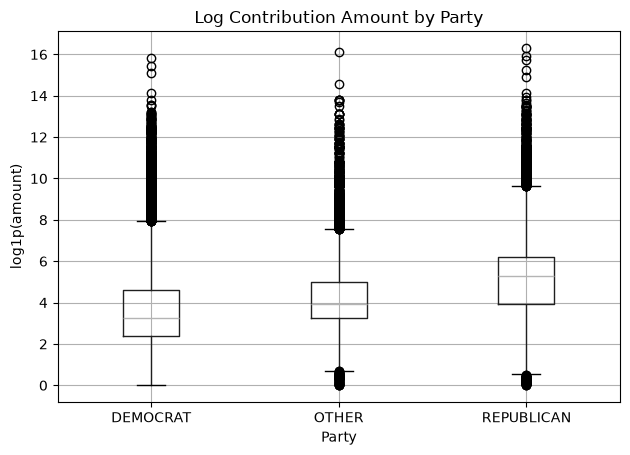

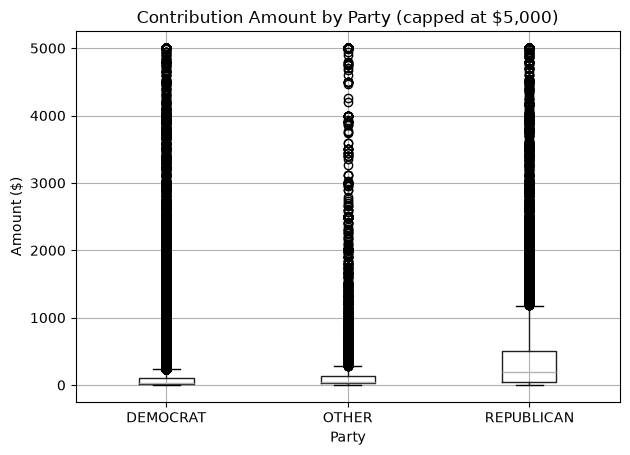

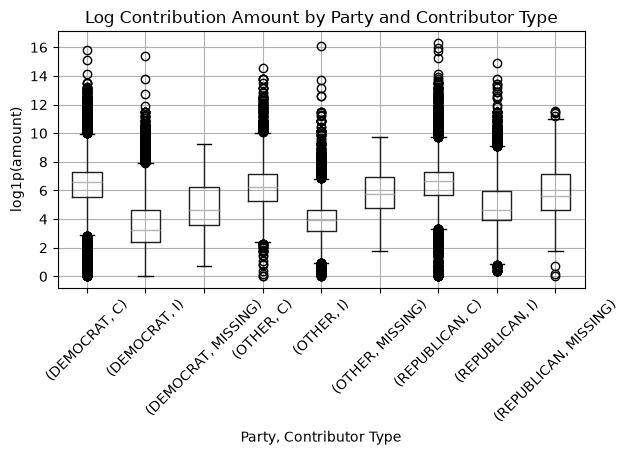

In [ ]:
if MAKE_GRAPHS:
    sample_fraction = 0.25

    # 1. Log contribution amount by party -- standard for right-skewed monetary distributions
    amount_log_pd = (
        contrib_model_df
        .select("party_group", F.log1p(F.col("amount")).alias("log_amount"))
        .sample(False, sample_fraction, seed=RANDOM_SEED)
        .toPandas()
    )
    if len(amount_log_pd) > 0:
        ax = amount_log_pd.boxplot(column="log_amount", by="party_group")
        ax.set_title("Log Contribution Amount by Party")
        ax.set_xlabel("Party")
        ax.set_ylabel("log1p(amount)")
        plt.suptitle("")
        plt.tight_layout()
        plt.show()

    # 2. Raw contribution amount by party, capped at $5,000 (per codebook's own
    #    capping convention (Section 6) for the largest itemized contributions)
    amount_capped_pd = (contrib_model_df
        .select("party_group", "amount")
        .filter(F.col("amount") <= 5000)
        .sample(False, sample_fraction, seed=RANDOM_SEED)
        .toPandas()
    )
    if len(amount_capped_pd) > 0:
        ax = amount_capped_pd.boxplot(column="amount", by="party_group")
        ax.set_title("Contribution Amount by Party (capped at $5,000)")
        ax.set_xlabel("Party")
        ax.set_ylabel("Amount ($)")
        plt.suptitle("")
        plt.tight_layout()
        plt.show()

    # 3. Log amount by party AND contributor type -- individual vs. committee/
    #    organization donors give at very different scales, so this checks whether
    #    the pooled party pattern above is actually being driven by one donor type.
    amount_type_pd = (
        contrib_model_df
        .select("party_group", "contributor_type", F.log1p(F.col("amount")).alias("log_amount"))
        .sample(False, sample_fraction, seed=RANDOM_SEED)
        .toPandas()
    )
    if len(amount_type_pd) > 0:
        ax = amount_type_pd.boxplot(column="log_amount", by=["party_group", "contributor_type"], rot=45)
        ax.set_title("Log Contribution Amount by Party and Contributor Type")
        ax.set_xlabel("Party, Contributor Type")
        ax.set_ylabel("log1p(amount)")
        plt.suptitle("")
        plt.tight_layout()
        plt.show()

In [102]:
contrib_model_df.groupBy("contributor_type").count().orderBy(F.desc("count")).show(10, truncate=False)

+----------------+-------+
|contributor_type|count  |
+----------------+-------+
|I               |1872109|
|C               |198690 |
|MISSING         |1210   |
|FEDERAL:SENATE  |1      |
+----------------+-------+



In [ ]:
# 1. 100% stacked bar: party share within each occupation group (top 15 by volume)

occupation_party_pct = (
    contrib_model_df
    .groupBy("occupation_group", "party_group")
    .count()
    .withColumn("occupation_total", F.sum("count").over(Window.partitionBy("occupation_group")))
    .withColumn("party_pct", F.col("count") / F.col("occupation_total"))
)

print("Party share by occupation group:")
show_df(occupation_party_pct.orderBy(F.desc("occupation_total"), "occupation_group", "party_group"), 200)

if MAKE_GRAPHS:
    occupation_party_pd = occupation_party_pct.select(
        "occupation_group", "party_group", "party_pct", "occupation_total"
    ).toPandas()
    if len(occupation_party_pd) > 0:
        top_occupations = (
            occupation_party_pd.drop_duplicates("occupation_group")
            .sort_values("occupation_total", ascending=False)
            .head(15)["occupation_group"]
            .tolist()
        )
        plot_df = occupation_party_pd[occupation_party_pd["occupation_group"].isin(top_occupations)]
        pivot_occ_pct = (
            plot_df.pivot_table(index="occupation_group", columns="party_group", values="party_pct", aggfunc="sum")
            .fillna(0)
            .loc[top_occupations]
        )
        ax = pivot_occ_pct.plot(kind="bar", stacked=True, title="Party Share by Occupation Group (Top 15 by volume)")
        ax.set_xlabel("Occupation group")
        ax.set_ylabel("Share of contributions")
        ax.legend(title="Party", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

+-----------------+-----------+------+-----------+--------------------+
|contributor_state|party_group|count |state_total|party_pct           |
+-----------------+-----------+------+-----------+--------------------+
|CA               |DEMOCRAT   |223092|290081     |0.7690679499863831  |
|CA               |OTHER      |25079 |290081     |0.08645516252357101 |
|CA               |REPUBLICAN |41910 |290081     |0.1444768874900459  |
|NY               |DEMOCRAT   |110361|135328     |0.8155075076850319  |
|NY               |OTHER      |5161  |135328     |0.03813697091510995 |
|NY               |REPUBLICAN |19806 |135328     |0.14635552139985814 |
|TX               |DEMOCRAT   |62362 |116794     |0.5339486617463226  |
|TX               |OTHER      |9043  |116794     |0.07742692261588781 |
|TX               |REPUBLICAN |45389 |116794     |0.3886244156377896  |
|FL               |DEMOCRAT   |66504 |106248     |0.6259317822453129  |
|FL               |OTHER      |5444  |106248     |0.051238611550

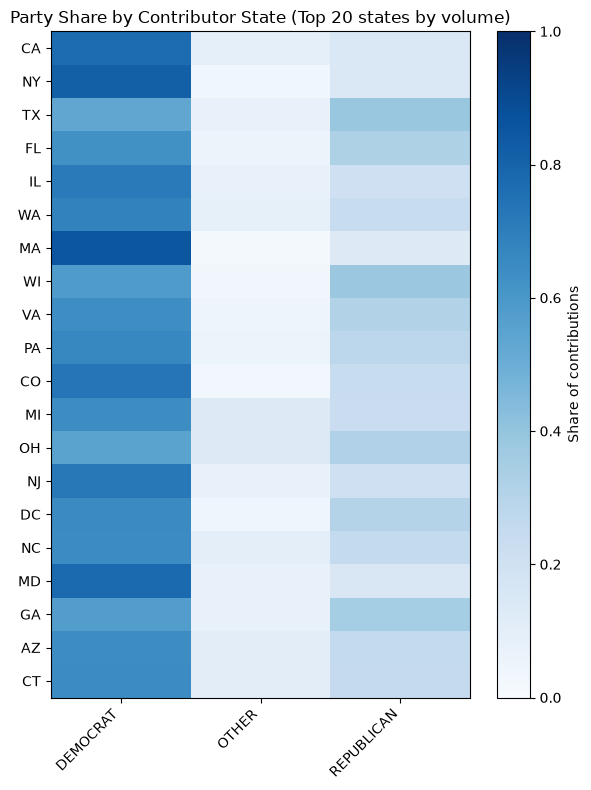

In [104]:
# 2. Heatmap: party share by contributor state (top 20 states by volume)

state_party_counts = contrib_model_df.groupBy("contributor_state", "party_group").count()

state_totals = (
    state_party_counts
    .groupBy("contributor_state")
    .agg(F.sum("count").alias("state_total"))
    .orderBy(F.desc("state_total"))
)

top_states = [row["contributor_state"] for row in state_totals.limit(20).collect()]

state_party_pct = (
    state_party_counts
    .join(state_totals, on="contributor_state")
    .withColumn("party_pct", F.col("count") / F.col("state_total"))
    .filter(F.col("contributor_state").isin(top_states))
)

print("Party share by contributor state (top 20 by volume):")
show_df(state_party_pct.orderBy(F.desc("state_total"), "contributor_state", "party_group"), 100)

if MAKE_GRAPHS:
    state_party_pd = state_party_pct.select("contributor_state", "party_group", "party_pct").toPandas()
    if len(state_party_pd) > 0:
        heatmap_pivot = state_party_pd.pivot_table(
            index="contributor_state", columns="party_group", values="party_pct", aggfunc="sum"
        ).fillna(0)
        heatmap_pivot = heatmap_pivot.loc[[s for s in top_states if s in heatmap_pivot.index]]

        fig, ax = plt.subplots(figsize=(6, 8))
        im = ax.imshow(heatmap_pivot.values, aspect="auto", cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks(range(len(heatmap_pivot.columns)))
        ax.set_xticklabels(heatmap_pivot.columns, rotation=45, ha="right")
        ax.set_yticks(range(len(heatmap_pivot.index)))
        ax.set_yticklabels(heatmap_pivot.index)
        ax.set_title("Party Share by Contributor State (Top 20 states by volume)")
        fig.colorbar(im, ax=ax, label="Share of contributions")
        plt.tight_layout()
        plt.show()

In [ ]:
# 3. Grouped bar: median log contribution amount by seat group and party (top 10 seats by volume)

seat_party_median_amount = (
    contrib_model_df
    .withColumn("log_amount", F.log1p(F.col("amount")))
    .groupBy("seat_group", "party_group")
    .agg(
        F.expr("percentile_approx(log_amount, 0.5)").alias("median_log_amount"),
        F.count("*").alias("rows"),
    )
)

seat_totals_amount = (
    seat_party_median_amount
    .groupBy("seat_group")
    .agg(F.sum("rows").alias("seat_total"))
    .orderBy(F.desc("seat_total"))
)

top_seats_amount = [row["seat_group"] for row in seat_totals_amount.limit(10).collect()]

print("Median log contribution amount by seat group and party:")
show_df(seat_party_median_amount.orderBy(F.desc("rows")), 50)

if MAKE_GRAPHS:
    seat_median_pd = (
        seat_party_median_amount
        .filter(F.col("seat_group").isin(top_seats_amount))
        .select("seat_group", "party_group", "median_log_amount")
        .toPandas()
    )
    if len(seat_median_pd) > 0:
        pivot_median = (
            seat_median_pd.pivot_table(index="seat_group", columns="party_group", values="median_log_amount", aggfunc="sum")
            .loc[[s for s in top_seats_amount if s in seat_median_pd["seat_group"].unique()]]
        )
        ax = pivot_median.plot(kind="bar", title="Median Log Contribution Amount by Seat Group and Party (Top 10 by volume)")
        ax.set_xlabel("Seat group")
        ax.set_ylabel("Median log1p(amount)")
        ax.legend(title="Party")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

In [ ]:
# 4. Weekly contribution volume over time, split by party

contrib_dated = contrib_model_df.withColumn(
    "transaction_date",
    F.coalesce(
        F.to_date("transaction_date_raw", "yyyy-MM-dd"),
        F.to_date("transaction_date_raw", "MM/dd/yyyy"),
        F.to_date("transaction_date_raw", "M/d/yyyy"),
    )
)

parsed_count = contrib_dated.filter(F.col("transaction_date").isNotNull()).count()
total_count = contrib_dated.count()
print(f"Parsed transaction_date for {parsed_count} of {total_count} rows ({parsed_count / total_count:.1%}).")
print("If this coverage is low, the date format above doesn't match this cycle's raw dates -- check a sample of transaction_date_raw.")

date_party_counts = (
    contrib_dated
    .filter(F.col("transaction_date").isNotNull())
    .withColumn("week", F.date_trunc("week", F.col("transaction_date")))
    .groupBy("week", "party_group")
    .count()
    .orderBy("week")
)

if MAKE_GRAPHS:
    date_party_pd = date_party_counts.toPandas()
    if len(date_party_pd) > 0:
        pivot_week = date_party_pd.pivot(index="week", columns="party_group", values="count").fillna(0)
        ax = pivot_week.plot(kind="line", marker="o", title="Weekly Contribution Volume by Party")
        ax.set_xlabel("Week")
        ax.set_ylabel("Number of contributions")
        ax.legend(title="Party")
        plt.tight_layout()
        plt.show()

# Data Splitting, Cross-Validation, Hyperparameter Tuning, and Modeling

Model construction, evaluation, and K-fold cross-validation of hyperparameters. This section uses a held-out test set and runs cross-validation only on the training data.

In [ ]:
def add_donor_split(
    df: DataFrame,
    id_col: str,
    test_fraction: float,
    seed: int,
    split_col: str = "split",
    num_buckets: int = 1000,
) -> DataFrame:
    # Same donor always hashes to the same bucket -> always lands on the same side.
    bucket = F.pmod(F.hash(F.col(id_col), F.lit(seed)), F.lit(num_buckets))
    threshold = int(round(test_fraction * num_buckets))
    return df.withColumn(split_col, F.when(bucket < threshold, F.lit("test")).otherwise(F.lit("train")))

contrib_model_df = add_donor_split(contrib_model_df, "bonica_cid", TEST_FRACTION, RANDOM_SEED)

print("Rows by split:")
show_df(contrib_model_df.groupBy("split").count(), 5)

train_donor_count = contrib_model_df.filter(F.col("split") == "train").select("bonica_cid").distinct().count()
test_donor_count = contrib_model_df.filter(F.col("split") == "test").select("bonica_cid").distinct().count()
print("Train distinct donors:", train_donor_count, " Test distinct donors:", test_donor_count)

# Sanity check -- should always be 0 by construction, but confirm it.
overlap_count = (
    contrib_model_df.filter(F.col("split") == "train").select("bonica_cid").distinct()
    .intersect(contrib_model_df.filter(F.col("split") == "test").select("bonica_cid").distinct())
    .count()
)
print("Donor overlap between train/test (should be 0):", overlap_count)

print("Party balance by split (should be roughly similar train vs test):")
show_df(contrib_model_df.groupBy("split", "party_group").count().orderBy("split", F.desc("count")), 20)

train_only_df = contrib_model_df.filter(F.col("split") == "train")

contrib_model_df, occupation_canonical, occupation_fuzzy_map = build_bucket_with_fuzzy_match(
    fit_df=train_only_df,       # vocabulary/fuzzy-map fit on TRAIN ONLY
    apply_df=contrib_model_df,  # applied to both train and test rows
    col_name="contributor_occupation_clean",
    top_n=OCCUPATION_TOP_N,
    out_col="occupation_group",
    synonym_map=OCCUPATION_SYNONYMS,
    contains_exclude=FUZZY_CONTAINS_EXCLUDE,
)

# ---- Step 7: donor-level feature/label wiring for the ContribDB party model ----
# CONTRIB_TRAIN_PARQUET / CONTRIB_TEST_PARQUET are now defined earlier, in the config cell,
# so the raw-file download cell can check them too.

contrib_model_df = contrib_model_df.withColumn("log_amount", F.log1p(F.col("amount")))

def materialize_split(df: DataFrame, out_path: Path, force: bool = False) -> DataFrame:
    if not force and parquet_has_data(out_path):
        return spark.read.parquet(str(out_path))
    df.repartition(MODEL_PARTITIONS).write.mode("overwrite").option("compression", "snappy").parquet(str(out_path))
    return spark.read.parquet(str(out_path))

contrib_train_df = materialize_split(contrib_model_df.filter(F.col("split") == "train"), CONTRIB_TRAIN_PARQUET)
contrib_test_df = materialize_split(contrib_model_df.filter(F.col("split") == "test"), CONTRIB_TEST_PARQUET)

print("Contrib train rows:", contrib_train_df.count(), " Contrib test rows:", contrib_test_df.count())

# NOTE: no manual label indexing here -- build_preprocess_stages() (in the modeling section below)
# already includes StringIndexer(inputCol="party_group", outputCol="label", ...) as its first
# pipeline stage. Adding a "label" column here too would collide with that stage's output column.
# contrib_train_df/contrib_test_df just need "party_group" present, which they already have.

# ---- Namespaced feature lists ----
contrib_numeric_features = ["log_amount"]
contrib_categorical_features = [
    "occupation_group",
    "transaction_type",
    "seat_group",
    "contributor_state",
    "recipient_state_group",
    "election_type_group",
    "contributor_gender",
    "contributor_type",
]

print("Contrib numeric features:", contrib_numeric_features)
print("Contrib categorical features:", contrib_categorical_features)


## Initialize Cross Validation Evalutation

In [ ]:
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
evaluator_weighted_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_weighted_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

# Cross-validation optimizes weighted F1.
cv_evaluator = evaluator_f1

def build_preprocess_stages(numeric_cols, categorical_cols, output_features_col="features", scale_numeric=True):
    label_indexer = StringIndexer(inputCol="party_group", outputCol="label", handleInvalid="skip")

    cat_indexers = [
        StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
        for c in categorical_cols
    ]

    encoder = OneHotEncoder(
        inputCols=[f"{c}_idx" for c in categorical_cols],
        outputCols=[f"{c}_ohe" for c in categorical_cols],
        handleInvalid="keep"
    )

    assembler_inputs = numeric_cols + [f"{c}_ohe" for c in categorical_cols]

    assembler = VectorAssembler(
        inputCols=assembler_inputs,
        outputCol="features_raw",
        handleInvalid="keep"
    )

    stages = [label_indexer] + cat_indexers + [encoder, assembler]

    if scale_numeric:
        scaler = StandardScaler(
            inputCol="features_raw",
            outputCol=output_features_col,
            withMean=False,
            withStd=True
        )
        stages.append(scaler)

    return stages

def get_label_names_from_pipeline_model(model):
    for st in model.stages:
        if hasattr(st, "labels"):
            return list(st.labels)
    return []

def compute_multiclass_ovr_auc(pred_df, labels):
    if "probability" not in pred_df.columns:
        return {"macro_ovr_auc": None, "weighted_ovr_auc": None}

    label_counts = {
        row["label"]: row["count"]
        for row in pred_df.groupBy("label").count().collect()
    }
    total = sum(label_counts.values())
    if total == 0:
        return {"macro_ovr_auc": None, "weighted_ovr_auc": None}

    prob_df = pred_df.withColumn("prob_array", vector_to_array(F.col("probability")))

    binary_eval = BinaryClassificationEvaluator(
        labelCol="binary_label",
        rawPredictionCol="score",
        metricName="areaUnderROC"
    )

    aucs = []
    weighted_parts = []

    for i, label_name in enumerate(labels):
        tmp = (
            prob_df
            .select(
                F.when(F.col("label") == float(i), 1.0).otherwise(0.0).alias("binary_label"),
                F.col("prob_array")[i].alias("score")
            )
            .filter(F.col("score").isNotNull())
        )

        pos_neg = tmp.groupBy("binary_label").count().collect()
        if len(pos_neg) < 2:
            auc = None
        else:
            auc = binary_eval.evaluate(tmp)

        if auc is not None:
            aucs.append(float(auc))
            weighted_parts.append(float(auc) * (label_counts.get(float(i), 0) / total))

    return {
        "macro_ovr_auc": sum(aucs) / len(aucs) if aucs else None,
        "weighted_ovr_auc": sum(weighted_parts) if weighted_parts else None,
    }

def evaluate_predictions(pred_df, model_name, labels):
    metrics = {
        "model": model_name,
        "accuracy": evaluator_acc.evaluate(pred_df),
        "weighted_f1": evaluator_f1.evaluate(pred_df),
        "weighted_precision": evaluator_weighted_precision.evaluate(pred_df),
        "weighted_recall": evaluator_weighted_recall.evaluate(pred_df),
    }

    try:
        metrics.update(compute_multiclass_ovr_auc(pred_df, labels))
    except Exception as e:
        print(f"AUROC could not be computed for {model_name}: {e}")
        metrics["macro_ovr_auc"] = None
        metrics["weighted_ovr_auc"] = None

    return metrics

def confusion_table(pred_df, labels):
    mapping = spark.createDataFrame(
        [(float(i), label) for i, label in enumerate(labels)],
        ["label_index", "label_name"]
    )

    pred_mapping = spark.createDataFrame(
        [(float(i), label) for i, label in enumerate(labels)],
        ["prediction_index", "prediction_name"]
    )

    return (
        pred_df
        .groupBy("label", "prediction")
        .count()
        .join(mapping, F.col("label") == F.col("label_index"), "left")
        .join(pred_mapping, F.col("prediction") == F.col("prediction_index"), "left")
        .select("label_name", "prediction_name", "count")
        .orderBy("label_name", "prediction_name")
    )

def cv_results_table(cv_model, param_names, model_name):
    rows = []
    for param_map, metric in zip(cv_model.getEstimatorParamMaps(), cv_model.avgMetrics):
        row = {"model": model_name, "cv_weighted_f1": float(metric)}
        for param_obj, display_name in param_names:
            row[display_name] = str(param_map.get(param_obj, None))
        rows.append(row)

    if not rows:
        rows = [{"model": model_name, "cv_weighted_f1": None}]

    return spark.createDataFrame(pd.DataFrame(rows))

In [ ]:
def get_stage_by_type(pipeline_model, type_name: str):
    for st in pipeline_model.stages:
        if st.__class__.__name__ == type_name:
            return st
    return None

def get_stages_by_type(pipeline_model, type_name: str):
    return [st for st in pipeline_model.stages if st.__class__.__name__ == type_name]

def build_feature_names_from_pipeline_model(pipeline_model, numeric_cols, categorical_cols):
    """
    Reconstructs the feature vector names after:
    StringIndexer -> OneHotEncoder -> VectorAssembler.

    Numeric features appear first. Then OHE categorical levels are expanded.
    """
    feature_names = list(numeric_cols)

    # StringIndexerModels have inputCol and labels.
    indexer_models = {
        st.getInputCol(): list(st.labels)
        for st in pipeline_model.stages
        if st.__class__.__name__ == "StringIndexerModel" and st.getInputCol() in categorical_cols
    }

    # OHE usually drops the last category by default. If dropLast=True, vector size is len(labels)-1.
    encoder_model = get_stage_by_type(pipeline_model, "OneHotEncoderModel")
    drop_last = True
    category_sizes = None
    if encoder_model is not None:
        try:
            drop_last = encoder_model.getDropLast()
        except Exception:
            drop_last = True
        try:
            category_sizes = list(encoder_model.categorySizes)
        except Exception:
            category_sizes = None

    for idx, c in enumerate(categorical_cols):
        labels = indexer_models.get(c, [])
        if category_sizes is not None and idx < len(category_sizes):
            size = int(category_sizes[idx])
        else:
            size = max(len(labels) - 1, 1) if drop_last else len(labels)

        for j in range(size):
            if j < len(labels):
                feature_names.append(f"{c}={labels[j]}")
            else:
                feature_names.append(f"{c}=__unknown_{j}")

    return feature_names

def random_forest_feature_importance_df(cv_model, numeric_cols, categorical_cols, model_name="Random Forest"):
    best_pipeline = cv_model.bestModel
    rf_model = best_pipeline.stages[-1]

    feature_names = build_feature_names_from_pipeline_model(best_pipeline, numeric_cols, categorical_cols)
    importances = rf_model.featureImportances.toArray().tolist()

    # Align lengths safely.
    n = min(len(feature_names), len(importances))
    rows = [(model_name, feature_names[i], float(importances[i])) for i in range(n)]

    # Add unnamed features if Spark vector is longer than reconstructed names.
    if len(importances) > len(feature_names):
        for i in range(len(feature_names), len(importances)):
            rows.append((model_name, f"feature_{i}", float(importances[i])))

    return spark.createDataFrame(rows, ["model", "feature", "importance"]).orderBy(F.desc("importance"))

def logistic_coefficient_importance_df(cv_model, numeric_cols, categorical_cols, model_name="Logistic Regression"):
    """
    For multinomial logistic regression, coefficientMatrix is classes x features.
    We summarize feature importance as the mean absolute coefficient across classes.
    """
    best_pipeline = cv_model.bestModel
    lr_model = best_pipeline.stages[-1]

    feature_names = build_feature_names_from_pipeline_model(best_pipeline, numeric_cols, categorical_cols)
    coef_matrix = lr_model.coefficientMatrix.toArray()

    mean_abs = abs(coef_matrix).mean(axis=0).tolist()

    n = min(len(feature_names), len(mean_abs))
    rows = [(model_name, feature_names[i], float(mean_abs[i])) for i in range(n)]

    if len(mean_abs) > len(feature_names):
        for i in range(len(feature_names), len(mean_abs)):
            rows.append((model_name, f"feature_{i}", float(mean_abs[i])))

    return spark.createDataFrame(rows, ["model", "feature", "mean_abs_coefficient"]).orderBy(F.desc("mean_abs_coefficient"))

def group_ohe_importance(importance_df: DataFrame, value_col: str):
    """
    Groups one-hot encoded feature levels back to the original feature name.
    Example: state_group=CA, state_group=NY -> state_group.
    """
    grouped = (
        importance_df
        .withColumn(
            "feature_group",
            F.when(F.col("feature").contains("="), F.split(F.col("feature"), "=").getItem(0))
             .otherwise(F.col("feature"))
        )
        .groupBy("model", "feature_group")
        .agg(F.sum(F.col(value_col)).alias(f"grouped_{value_col}"))
        .orderBy(F.desc(f"grouped_{value_col}"))
    )
    return grouped

# Model 1: Benchmark Logistic Regression with CV

In [ ]:
benchmark_numeric = [c for c in ["log_amount"] if c in contrib_numeric_features]
benchmark_categorical = [c for c in ["seat_group"] if c in contrib_categorical_features]

benchmark_preprocess = build_preprocess_stages(
    benchmark_numeric,
    benchmark_categorical,
    output_features_col="features",
    scale_numeric=True
)

benchmark_lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    family="multinomial",
    maxIter=30
)

benchmark_pipeline = Pipeline(stages=benchmark_preprocess + [benchmark_lr])

if FAST_CV:
    benchmark_grid = (
        ParamGridBuilder()
        .addGrid(benchmark_lr.regParam, [0.0, 0.05])
        .addGrid(benchmark_lr.elasticNetParam, [0.0])
        .build()
    )
else:
    benchmark_grid = (
        ParamGridBuilder()
        .addGrid(benchmark_lr.regParam, [0.0, 0.01, 0.05, 0.1])
        .addGrid(benchmark_lr.elasticNetParam, [0.0, 0.5])
        .build()
    )

benchmark_cv = CrossValidator(
    estimator=benchmark_pipeline,
    estimatorParamMaps=benchmark_grid,
    evaluator=cv_evaluator,
    numFolds=NUM_FOLDS,
    parallelism=max(1, min(NUM_CORES, 4)),
    seed=RANDOM_SEED
)

benchmark_cv_model = benchmark_cv.fit(contrib_train_df)
benchmark_pred = benchmark_cv_model.transform(contrib_test_df)
benchmark_labels = get_label_names_from_pipeline_model(benchmark_cv_model.bestModel)

benchmark_metrics = evaluate_predictions(benchmark_pred, "Benchmark Logistic Regression", benchmark_labels)
benchmark_metrics

In [ ]:
# Benchmark CV sensitivity table and confusion matrix
benchmark_cv_table = cv_results_table(
    benchmark_cv_model,
    [(benchmark_lr.regParam, "regParam"), (benchmark_lr.elasticNetParam, "elasticNetParam")],
    "Benchmark Logistic Regression"
).orderBy(F.desc("cv_weighted_f1"))

show_df(benchmark_cv_table, 50)
show_df(confusion_table(benchmark_pred, benchmark_labels), 100)

# Model 2: Full Multinomial Logistic Regression with CV

In [ ]:
full_lr_preprocess = build_preprocess_stages(
    contrib_numeric_features,
    contrib_categorical_features,
    output_features_col="features",
    scale_numeric=True
)

full_lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    family="multinomial",
    maxIter=60
)

full_lr_pipeline = Pipeline(stages=full_lr_preprocess + [full_lr])

if FAST_CV:
    full_lr_grid = (
        ParamGridBuilder()
        .addGrid(full_lr.regParam, [0.01, 0.05])
        .addGrid(full_lr.elasticNetParam, [0.0, 0.5])
        .build()
    )
else:
    full_lr_grid = (
        ParamGridBuilder()
        .addGrid(full_lr.regParam, [0.001, 0.01, 0.05, 0.1])
        .addGrid(full_lr.elasticNetParam, [0.0, 0.25, 0.5, 1.0])
        .build()
    )

full_lr_cv = CrossValidator(
    estimator=full_lr_pipeline,
    estimatorParamMaps=full_lr_grid,
    evaluator=cv_evaluator,
    numFolds=NUM_FOLDS,
    parallelism=max(1, min(NUM_CORES, 4)),
    seed=RANDOM_SEED
)

full_lr_cv_model = full_lr_cv.fit(contrib_train_df)
full_lr_pred = full_lr_cv_model.transform(contrib_test_df)
full_lr_labels = get_label_names_from_pipeline_model(full_lr_cv_model.bestModel)

full_lr_metrics = evaluate_predictions(full_lr_pred, "Full Multinomial Logistic Regression", full_lr_labels)
full_lr_metrics

In [ ]:
full_lr_cv_table = cv_results_table(
    full_lr_cv_model,
    [(full_lr.regParam, "regParam"), (full_lr.elasticNetParam, "elasticNetParam")],
    "Full Multinomial Logistic Regression"
).orderBy(F.desc("cv_weighted_f1"))

show_df(full_lr_cv_table, 100)
show_df(confusion_table(full_lr_pred, full_lr_labels), 100)

# Model 3: Random Forest with CV

In [ ]:
rf_preprocess = build_preprocess_stages(
    contrib_numeric_features,
    contrib_categorical_features,
    output_features_col="features",
    scale_numeric=False
)

rf = RandomForestClassifier(
    featuresCol="features_raw",
    labelCol="label",
    seed=RANDOM_SEED
)

rf_pipeline = Pipeline(stages=rf_preprocess + [rf])

if FAST_CV:
    rf_grid = (
        ParamGridBuilder()
        .addGrid(rf.numTrees, [50])
        .addGrid(rf.maxDepth, [5])
        .addGrid(rf.featureSubsetStrategy, ["sqrt"])
        .build()
    )
else:
    rf_grid = (
        ParamGridBuilder()
        .addGrid(rf.numTrees, [50, 100, 150])
        .addGrid(rf.maxDepth, [5, 8, 12])
        .addGrid(rf.featureSubsetStrategy, ["sqrt", "log2"])
        .build()
    )

rf_cv = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=rf_grid,
    evaluator=cv_evaluator,
    numFolds=NUM_FOLDS,
    parallelism=max(1, min(NUM_CORES, 5)),
    seed=RANDOM_SEED
)

rf_cv_model = rf_cv.fit(contrib_train_df)
rf_pred = rf_cv_model.transform(contrib_test_df)
rf_labels = get_label_names_from_pipeline_model(rf_cv_model.bestModel)

rf_metrics = evaluate_predictions(rf_pred, "Random Forest", rf_labels)
rf_metrics

In [ ]:
rf_cv_table = cv_results_table(
    rf_cv_model,
    [(rf.numTrees, "numTrees"), (rf.maxDepth, "maxDepth"), (rf.featureSubsetStrategy, "featureSubsetStrategy")],
    "Random Forest"
).orderBy(F.desc("cv_weighted_f1"))

show_df(rf_cv_table, 100)
show_df(confusion_table(rf_pred, rf_labels), 100)

# Model Importance

This section adds interpretability outputs:

1. **Random Forest feature importance** from the tuned champion candidate.
2. **Grouped Random Forest importance**, where one-hot encoded levels are grouped back to the original column.
3. **Logistic Regression coefficient importance**, based on mean absolute coefficients across party classes.

In [ ]:
# Random Forest feature importance

rf_importance_df = random_forest_feature_importance_df(
    rf_cv_model,
    contrib_numeric_features,
    contrib_categorical_features,
    model_name="Random Forest"
)

print("Top Random Forest feature importances:")
show_df(rf_importance_df, 50, truncate=False)

rf_grouped_importance_df = group_ohe_importance(rf_importance_df, "importance")

print("Grouped Random Forest feature importances:")
show_df(rf_grouped_importance_df, 50, truncate=False)

if MAKE_GRAPHS:
    rf_imp_pd = rf_grouped_importance_df.limit(20).toPandas()
    if len(rf_imp_pd) > 0:
        ax = rf_imp_pd.sort_values("grouped_importance").plot(
            kind="barh",
            x="feature_group",
            y="grouped_importance",
            legend=False,
            title="Top Grouped Random Forest Feature Importances"
        )
        ax.set_xlabel("Grouped importance")
        ax.set_ylabel("Feature group")
        plt.tight_layout()
        plt.show()

In [ ]:
# Logistic Regression coefficient importance

full_lr_coef_importance_df = logistic_coefficient_importance_df(
    full_lr_cv_model,
    contrib_numeric_features,
    contrib_categorical_features,
    model_name="Full Multinomial Logistic Regression"
)

print("Top Logistic Regression coefficient importances:")
show_df(full_lr_coef_importance_df, 50, truncate=False)

full_lr_grouped_coef_importance_df = group_ohe_importance(
    full_lr_coef_importance_df.withColumnRenamed("mean_abs_coefficient", "coef_importance"),
    "coef_importance"
)

print("Grouped Logistic Regression coefficient importances:")
show_df(full_lr_grouped_coef_importance_df, 50, truncate=False)

if MAKE_GRAPHS:
    lr_imp_pd = full_lr_grouped_coef_importance_df.limit(20).toPandas()
    if len(lr_imp_pd) > 0:
        ax = lr_imp_pd.sort_values("grouped_coef_importance").plot(
            kind="barh",
            x="feature_group",
            y="grouped_coef_importance",
            legend=False,
            title="Top Grouped Logistic Regression Coefficient Importances"
        )
        ax.set_xlabel("Grouped mean absolute coefficient")
        ax.set_ylabel("Feature group")
        plt.tight_layout()
        plt.show()

In [ ]:
# 18. Model comparison and champion selection

metrics_rows = [benchmark_metrics, full_lr_metrics, rf_metrics]
metrics_pdf = pd.DataFrame(metrics_rows)

model_comparison = spark.createDataFrame(metrics_pdf).orderBy(F.desc("weighted_f1"))

show_df(model_comparison, 20)

champion_row = model_comparison.first().asDict()
champion_model_name = champion_row["model"]

print("Champion model:", champion_model_name)
print("Champion weighted F1:", champion_row["weighted_f1"])
print("Champion weighted AUROC:", champion_row.get("weighted_ovr_auc"))

# Save final outputs

In [ ]:
MODEL_OUTPUT_DIR = PROCESSED_DIR / f"final_project_outputs_{min(CONTRIB_MODEL_CYCLES)}_{max(CONTRIB_MODEL_CYCLES)}"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

model_comparison.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "model_comparison_parquet"))
benchmark_cv_table.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "benchmark_cv_results_parquet"))
full_lr_cv_table.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "full_lr_cv_results_parquet"))
rf_cv_table.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "rf_cv_results_parquet"))

# Save model importance outputs
rf_importance_df.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "rf_feature_importance_parquet"))
rf_grouped_importance_df.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "rf_grouped_feature_importance_parquet"))
full_lr_coef_importance_df.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "full_lr_coefficient_importance_parquet"))
full_lr_grouped_coef_importance_df.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "full_lr_grouped_coefficient_importance_parquet"))

# Save EDA outputs
occupation_party_pct.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "occupation_party_pct_parquet"))
state_party_pct.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "state_party_pct_parquet"))
seat_party_median_amount.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "seat_party_median_amount_parquet"))
date_party_counts.write.mode("overwrite").parquet(str(MODEL_OUTPUT_DIR / "date_party_counts_parquet"))

print("Saved outputs to:", MODEL_OUTPUT_DIR)